In [1]:
! pip install numpyro corner healpy einops reproject getdist

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 22.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.1/778.1 kB 17.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.3/198.3 kB 11.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.3/203.3 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 27.1 MB/s eta 0:00:00
  Created wheel for getdist: filename=GetDist-1.4.3-py3-none-any.whl size=227495 sha256=4731084fb2340d2ff9b0b3e584f96c72a07680fecd4f529f3f1dfaeffe0579b9
  Stored in directory: 

In [2]:
! sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern
  fonts-noto-mono fonts-texgyre fonts-urw-base35 ghostscript javascript-common
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libfontenc1 libgs9 libgs9-common libharfbuzz-icu0 libidn11
  libijs-0.35 libjbig2dec0 libjs-jquery libkpathsea6 libpdfbox-java
  libptexenc1 libruby2.7 libsynctex2 libteckit0 libtexlua53 libtexluajit2
  libwoff1 libzzip-0-13 lmodern pfb2t1c2pfb poppler-data preview-latex-style
  rake ruby ruby-minitest ruby-net-telnet ruby-power-assert ruby-test-unit
  ruby-xmlrpc ruby2.7 rubygems-integration t1utils tex-common tex-gyre
  texlive-base texlive-binaries texlive-fonts-recommended texlive-latex-base
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fon

In [3]:
import sys
from google.colab import drive
drive.mount('/content/drive')
sys.path.append(r'/content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/')

Mounted at /content/drive


In [4]:
%cd /content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks

/content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks


In [5]:
%reload_ext autoreload
%autoreload 2

import sys, os
sys.path.append("../")

import numpy as np
import corner
import pickle
from tqdm import tqdm

In [6]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [7]:
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18

## \# of pixels

In [ ]:
from models.np_model import NPModel

In [ ]:
npmodel = NPModel(
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [ ]:
print(npmodel.mask_roi.shape)
print(np.sum(~npmodel.mask_roi))

(196608,)
6839


## plot corner

In [ ]:
samples =  pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))

plot_var_names = ['gamma_ps', 'gamma_poiss', 'f_bulge_ps', 'C', 'zs']

n_bins_1d = 30
bins_1d_arr = []
for vn in plot_var_names:
    # vmin = np.min([np.min(s[vn]) for _, s in samples.items()])
    # vmax = np.max([np.max(s[vn]) for _, s in samples.items()])
    vmin = np.min(samples[vn])
    vmax = np.max(samples[vn])
    bins_1d_arr.append(np.linspace(vmin, vmax, n_bins_1d + 1))

figure = corner.corner(
    samples,
    bins_1d_arr=bins_1d_arr,
    var_names=plot_var_names,
    show_titles=False,
    title_kwargs={"fontsize": 18},
    levels = [0.68, 0.95],
    color = 'firebrick',
    plot_contours=True,
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=True, smooth1d=True,
    fig=None,
    alpha=1.0
)
#plt.savefig('corner_for_draft.pdf')

## getdist

In [12]:
from getdist import plots, MCSamples
import getdist

In [9]:
saved_samples = pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))
print(' '.join(list(saved_samples.keys())))

Alm_0 Alm_1 Alm_2 Alm_3 Alm_4 Alm_5 C S_bub S_dif S_gce S_ics S_iso S_psc Sps_dsk Sps_gce f_bulge_poiss f_bulge_ps gamma_poiss gamma_ps lambdas_dsk lambdas_gce n1_dsk n1_gce n2_dsk n2_gce n3_dsk n3_gce sb1_dsk sb1_gce theta_p_mcdermott2022 theta_p_mcdermott2022_bbp theta_p_mcdermott2022_x theta_p_macias2019 theta_p_coleman2019 theta_ps_mcdermott2022 theta_ps_mcdermott2022_bbp theta_ps_mcdermott2022_x theta_ps_macias2019 theta_ps_coleman2019 theta_MO_ics theta_MA_ics theta_MF_ics theta_MO_pib theta_MA_pib theta_MF_pib zs


In [14]:
saved_samples = pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))
f_gce_ps = saved_samples['Sps_gce'] / (saved_samples['S_gce'] + saved_samples['Sps_gce'])
f_bulge = (saved_samples['Sps_gce'] * saved_samples['f_bulge_ps'] \
           + saved_samples['S_gce'] * saved_samples['f_bulge_poiss']) / (saved_samples['S_gce'] + saved_samples['Sps_gce'])
post_plot = np.concatenate([
    [f_gce_ps],
    [saved_samples['f_bulge_ps']],
    [saved_samples['f_bulge_poiss']],
    [saved_samples['gamma_ps']],
    [saved_samples['gamma_poiss']],
    [saved_samples['zs']],
    [saved_samples['C']]], axis=0)

In [ ]:
# normal dists
post_plot = np.concatenate([
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))],
    [np.random.normal(size=(100000,))]], axis=0)

In [ ]:
def invert_rgba(rgba):
    rgb = rgba[:3]
    a = rgba[-1]
    return tuple(np.array([1, 1, 1] - np.array(rgb))) + (a,)

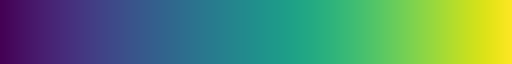

In [ ]:
mpl.cm.get_cmap('viridis')

In [15]:
g = plots.get_subplot_plotter(subplot_size=1.4)
g.settings.axes_fontsize=16
g.settings.fontsize=16
g.settings.rc_sizes(axes_fontsize=22, lab_fontsize=22)
g.settings.alpha_filled_add=0.4
g.settings.title_limit_fontsize=19
g.settings.title_limit=1
g.settings.title_limit_labels=0
g.settings.solid_contour_palefactor = 0.9

#color = mpl.colors.to_hex(invert_rgba(mpl.cm.get_cmap('viridis')(0.7)), keep_alpha=True)
color = 'firebrick'

names = [r'f_\mathrm{PS,\,GCE}', r'f_\mathrm{bulge,\,PS}', r'f_\mathrm{bulge, poiss}', r'\gamma_\mathrm{PS}', r'\gamma_\mathrm{poiss}', r'z_s', r'C']
samples = MCSamples(samples=post_plot.T, names = names, labels = names)

g.triangle_plot([samples],
    line_args=[{'lw':2, 'color':color}],
    filled=True,
    # title_limit=1,
    contour_colors=[color],)
g.export('np_sviiaf_par8_v2.pdf')

Removed no burn in
